# 📈 Notebook 03: Baseline Models

**Objective:** Establish baseline performance for NVIDIA stock price forecasting using simple models.

**Why Baselines Matter:**
- Any advanced model must outperform these simple benchmarks
- Helps understand the difficulty of the forecasting task
- Prevents overconfidence in complex model performance

**Models to Implement:**
1. Naive Forecast (tomorrow = today)
2. Moving Average Forecast
3. Seasonal Naive (weekly pattern)

**Key Challenge:** Proper time-series train-test splits to avoid data leakage.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Add parent directory to path
sys.path.append(os.path.abspath('..'))

from src.data.loader import NVDADataLoader
from src.features.engineering import FeatureEngineer

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 7)

## 1. Load and Prepare Data

Use the production data loader to ensure consistency with other notebooks.

In [2]:
# Load data
loader = NVDADataLoader('../data/raw/NVDA_yfinance_clean.csv')
df, report = loader.load_and_validate(verbose=True)

print(f"\nData shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

✅ Loaded 2,514 rows from NVDA_yfinance_clean.csv

                             📊 DATA QUALITY REPORT                              

📏 Dimensions: 2,514 rows × 6 columns
📅 Date Range: 2016-01-04 to 2025-12-31
🔢 Duplicate Rows: 0
❓ Total Missing Values: 0

--------------------------------------------------------------------------------
✅ VALIDATION PASSED - Data quality is excellent!


Data shape: (2514, 6)
Date range: 2016-01-04 00:00:00 to 2025-12-31 00:00:00


## 2. Time-Series Train-Test Split

**CRITICAL:** For time-series data, we cannot use random splits. Must respect temporal order!

In [3]:
# Time-series split: Use first 80% for training, last 20% for testing
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Training set: {len(train_df)} rows ({train_df['Date'].min()} to {train_df['Date'].max()})")
print(f"Test set: {len(test_df)} rows ({test_df['Date'].min()} to {test_df['Date'].max()})")

# Target variable: Next day's closing price
train_df['target'] = train_df['Close'].shift(-1)
test_df['target'] = test_df['Close'].shift(-1)

# Remove last row (no target)
train_df = train_df.dropna()
test_df = test_df.dropna()

print(f"\nAfter creating targets:")
print(f"Training set: {len(train_df)} rows")
print(f"Test set: {len(test_df)} rows")

Training set: 2011 rows (2016-01-04 00:00:00 to 2023-12-28 00:00:00)
Test set: 503 rows (2023-12-29 00:00:00 to 2025-12-31 00:00:00)

After creating targets:
Training set: 2010 rows
Test set: 502 rows


## 3. Baseline Model 1: Naive Forecast

**Logic:** Tomorrow's price = Today's price

This is the simplest possible forecast and often surprisingly effective for financial time-series.

In [4]:
# Naive forecast: predict tomorrow = today
test_df['naive_pred'] = test_df['Close']

# Calculate metrics
naive_mae = mean_absolute_error(test_df['target'], test_df['naive_pred'])
naive_rmse = np.sqrt(mean_squared_error(test_df['target'], test_df['naive_pred']))
naive_r2 = r2_score(test_df['target'], test_df['naive_pred'])

# Directional accuracy (did we predict up/down correctly?)
test_df['actual_direction'] = (test_df['target'] > test_df['Close']).astype(int)
test_df['naive_direction'] = (test_df['naive_pred'] > test_df['Close']).astype(int)
naive_dir_acc = (test_df['actual_direction'] == test_df['naive_direction']).mean()

print(f"Naive Forecast Performance:")
print(f"MAE: ${naive_mae:.2f}")
print(f"RMSE: ${naive_rmse:.2f}")
print(f"R²: {naive_r2:.4f}")
print(f"Directional Accuracy: {naive_dir_acc:.1%}")

Naive Forecast Performance:
MAE: $2.90
RMSE: $3.92
R²: 0.9885
Directional Accuracy: 45.4%


## 4. Baseline Model 2: Moving Average Forecast

**Logic:** Tomorrow's price = Average of last N days

Uses recent trend information. Common window sizes: 7, 30, 50 days.

In [5]:
# Moving average forecast using last 7 days
window = 7
test_df['ma_pred'] = test_df['Close'].rolling(window=window, min_periods=1).mean()

# For the first few days, use available data
for i in range(min(window, len(test_df))):
    if i == 0:
        test_df.iloc[i, test_df.columns.get_loc('ma_pred')] = test_df.iloc[i]['Close']
    else:
        test_df.iloc[i, test_df.columns.get_loc('ma_pred')] = test_df.iloc[:i+1]['Close'].mean()

# Calculate metrics
ma_mae = mean_absolute_error(test_df['target'], test_df['ma_pred'])
ma_rmse = np.sqrt(mean_squared_error(test_df['target'], test_df['ma_pred']))
ma_r2 = r2_score(test_df['target'], test_df['ma_pred'])

# Directional accuracy
test_df['ma_direction'] = (test_df['ma_pred'] > test_df['Close']).astype(int)
ma_dir_acc = (test_df['actual_direction'] == test_df['ma_direction']).mean()

print(f"{window}-Day Moving Average Forecast Performance:")
print(f"MAE: ${ma_mae:.2f}")
print(f"RMSE: ${ma_rmse:.2f}")
print(f"R²: {ma_r2:.4f}")
print(f"Directional Accuracy: {ma_dir_acc:.1%}")

7-Day Moving Average Forecast Performance:
MAE: $4.94
RMSE: $6.19
R²: 0.9713
Directional Accuracy: 50.8%


## 5. Baseline Model 3: Seasonal Naive

**Logic:** Tomorrow's price = Same day last week

Exploits weekly patterns in stock prices (Monday effect, weekend effects, etc.)

In [6]:
# Seasonal naive: use same day from previous week
test_df['seasonal_pred'] = test_df['Close'].shift(5)  # 5 trading days = 1 week

# For first 5 days, use naive forecast
test_df['seasonal_pred'] = test_df['seasonal_pred'].fillna(test_df['Close'])

# Calculate metrics
seasonal_mae = mean_absolute_error(test_df['target'], test_df['seasonal_pred'])
seasonal_rmse = np.sqrt(mean_squared_error(test_df['target'], test_df['seasonal_pred']))
seasonal_r2 = r2_score(test_df['target'], test_df['seasonal_pred'])

# Directional accuracy
test_df['seasonal_direction'] = (test_df['seasonal_pred'] > test_df['Close']).astype(int)
seasonal_dir_acc = (test_df['actual_direction'] == test_df['seasonal_direction']).mean()

print(f"Seasonal Naive (Weekly) Forecast Performance:")
print(f"MAE: ${seasonal_mae:.2f}")
print(f"RMSE: ${seasonal_rmse:.2f}")
print(f"R²: {seasonal_r2:.4f}")
print(f"Directional Accuracy: {seasonal_dir_acc:.1%}")

Seasonal Naive (Weekly) Forecast Performance:
MAE: $7.14
RMSE: $8.89
R²: 0.9408
Directional Accuracy: 50.6%


## 6. Model Comparison

Compare all baseline models side-by-side.

In [7]:
# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Naive', 'Moving Average (7-day)', 'Seasonal Naive'],
    'MAE': [naive_mae, ma_mae, seasonal_mae],
    'RMSE': [naive_rmse, ma_rmse, seasonal_rmse],
    'R²': [naive_r2, ma_r2, seasonal_r2],
    'Directional Accuracy': [naive_dir_acc, ma_dir_acc, seasonal_dir_acc]
})

# Format for display
results_display = results.copy()
results_display['MAE'] = results_display['MAE'].map('${:.2f}'.format)
results_display['RMSE'] = results_display['RMSE'].map('${:.2f}'.format)
results_display['R²'] = results_display['R²'].map('{:.4f}'.format)
results_display['Directional Accuracy'] = results_display['Directional Accuracy'].map('{:.1%}'.format)

print("Baseline Model Performance Comparison")
print("=" * 50)
print(results_display.to_string(index=False))

Baseline Model Performance Comparison
                 Model   MAE  RMSE     R² Directional Accuracy
                 Naive $2.90 $3.92 0.9885                45.4%
Moving Average (7-day) $4.94 $6.19 0.9713                50.8%
        Seasonal Naive $7.14 $8.89 0.9408                50.6%


## 7. Visualization

Plot actual vs predicted prices for a sample period.

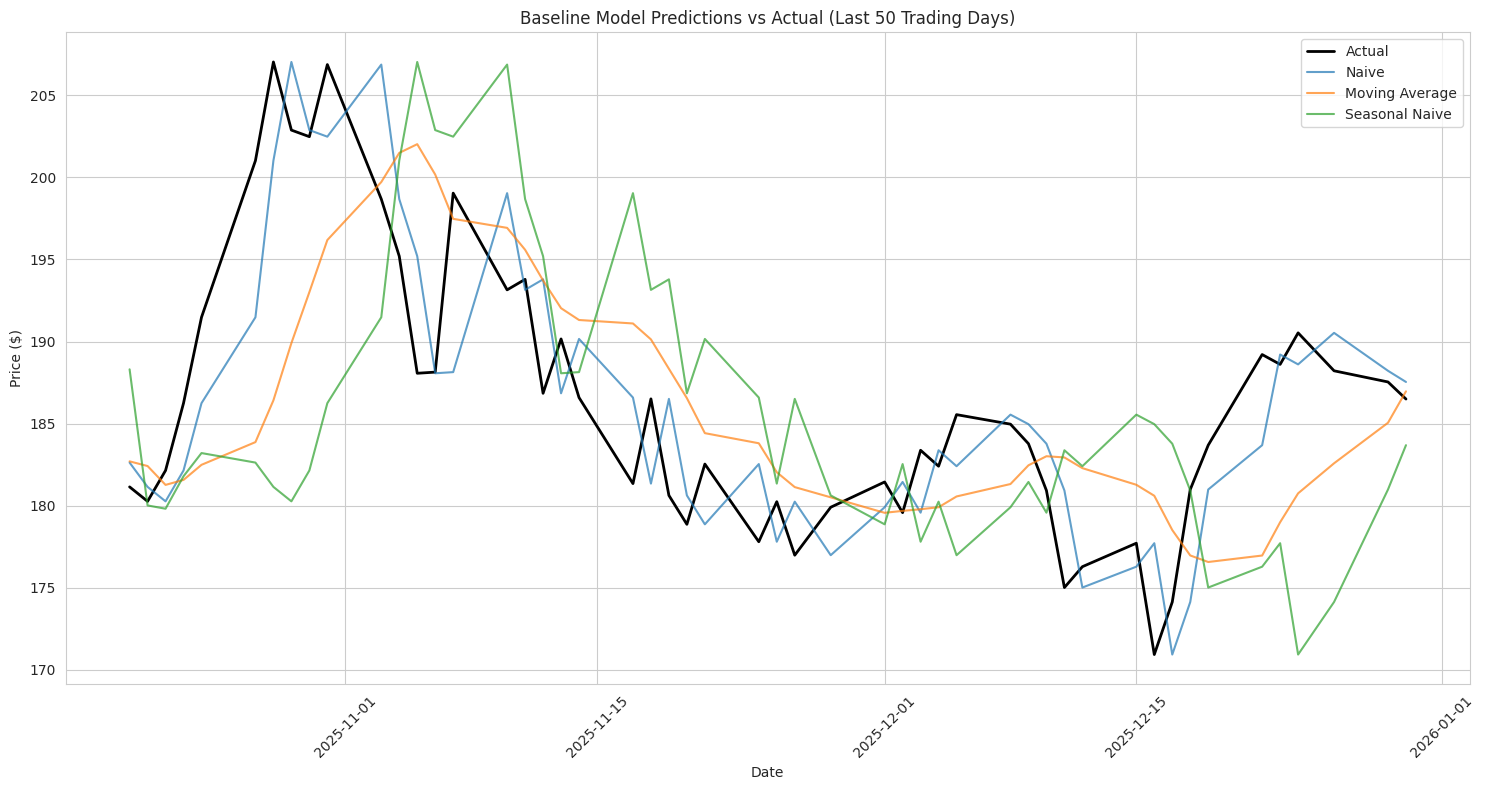

In [8]:
# Plot last 50 days of predictions
plot_df = test_df.tail(50).copy()

plt.figure(figsize=(15, 8))
plt.plot(plot_df['Date'], plot_df['target'], label='Actual', linewidth=2, color='black')
plt.plot(plot_df['Date'], plot_df['naive_pred'], label='Naive', alpha=0.7)
plt.plot(plot_df['Date'], plot_df['ma_pred'], label='Moving Average', alpha=0.7)
plt.plot(plot_df['Date'], plot_df['seasonal_pred'], label='Seasonal Naive', alpha=0.7)

plt.title('Baseline Model Predictions vs Actual (Last 50 Trading Days)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Key Insights

**What we learned:**
1. **Stock price forecasting is hard** - Even simple baselines show limited predictive power
2. **Directional accuracy matters** - For trading, predicting direction is often more important than exact price
3. **Recent trends help** - Moving average often outperforms naive forecast
4. **Weekly patterns exist** - Seasonal naive captures some market rhythm

**Next steps:** Any advanced model (ML, neural networks) must significantly outperform these baselines to be useful.